In [9]:
# Setup - Run this first
import sys
from pathlib import Path

# Add project to path (parent of notebooks folder)
project_dir = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(project_dir))

# Import new Screen + Track modules
from utils.tradingview_snapshot import load_tradingview_exports
from analysis.snapshot_ranker import rank_snapshot, print_top_stocks, load_config, DEFAULT_CONFIG
from analysis.snapshot_store import SnapshotStore, save_snapshot, load_snapshot
from analysis.snapshot_tracker import evaluate_forward_returns, print_evaluation, save_evaluation

import pandas as pd
import numpy as np
from datetime import datetime
from glob import glob

print("JSE Screen + Track System loaded!")
print(f"Project directory: {project_dir}")


# ## 1. Load TradingView Snapshot
# 
# Load and merge multiple TradingView screener CSV exports from the same date.
# Each export has different columns - the system merges them into one unified dataset.
from notebooks.nb_helpers import (
    load_report_cache,
    get_batch_report_insights,
    load_or_fetch_news,
    get_news_sentiment,
    data_freshness_banner,
    get_conviction_df,
    TONE_EMOJI
)


JSE Screen + Track System loaded!
Project directory: c:\Users\chris\Desktop\South_African_Stocks


In [10]:
# CONFIGURE: Set the snapshot date and path to your TradingView CSVs
SNAPSHOT_DATE = "2026-05-15"  # Change this to your export date
TV_DATA_PATH = Path(r"C:\Users\chris\Desktop\South_African_Stocks\data")

# Find all CSVs for this date
csv_pattern = TV_DATA_PATH / f"SA_Stocks_{SNAPSHOT_DATE}*.csv"
csv_files = list(TV_DATA_PATH.glob(f"SA_Stocks_{SNAPSHOT_DATE}*.csv"))

print(f"Snapshot Date: {SNAPSHOT_DATE}")
print(f"Found {len(csv_files)} CSV files:")
for f in csv_files[:5]:
    print(f"  - {f.name}")
if len(csv_files) > 5:
    print(f"  ... and {len(csv_files) - 5} more")


Snapshot Date: 2026-05-15
Found 11 CSV files:
  - SA_Stocks_2026-05-15 (1).csv
  - SA_Stocks_2026-05-15 (10).csv
  - SA_Stocks_2026-05-15 (2).csv
  - SA_Stocks_2026-05-15 (3).csv
  - SA_Stocks_2026-05-15 (4).csv
  ... and 6 more


## 1. Load TradingView Snapshot

Load and merge multiple TradingView screener CSV exports from the same date.
Each export has different columns - the system merges them into one unified dataset.

In [11]:
# Load and merge all CSV exports
merged_df, report = load_tradingview_exports(csv_files)

print(f"Merged {report.total_symbols} stocks with {report.columns_merged} columns")
print(f"Duplicates resolved: {report.duplicate_columns_resolved}")
if report.dropped_columns:
    print(f"Dropped: {', '.join(report.dropped_columns[:5])}")

# Preview the data
print(f"\nAvailable columns ({len(merged_df.columns)}):")
print(merged_df.columns.tolist()[:20])
print("...")

merged_df.head()


# ## 2. Rank Stocks by Growth Potential
# 
# Two ranking modes:
# - **Aggressive**: Higher momentum weight, lower gates (min coverage 50%, min liquidity 1M)
# - **Guardrails**: More balanced weights, stricter gates (min coverage 60%, min liquidity 10M, max D/E 2.0)
# 
# Note: This is NOT a backtest. Scores represent current growth potential based on available metrics.


Merged 245 stocks with 122 columns
Duplicates resolved: 20
Dropped: _analyst_rating, price_-_currency, pre-market_price_-_currency, post-market_price_-_currency, market_capitalization_-_currency

Available columns (103):
['symbol', 'description', 'price', 'price_change_1d', 'perf_1w', 'perf_1m', 'perf_3m', 'perf_6m', 'perf_ytd', 'perf_1y', 'perf_5y', 'performance_10_years', 'perf_all_time', 'vol_1w', 'vol_1m', 'technical_rating_1d', 'moving_averages_rating_1d', 'oscillators_rating_1d', 'rsi_14', 'momentum_10_1_day']
...


,symbol,description,price,price_change_1d,perf_1w,perf_1m,perf_3m,perf_6m,perf_ytd,perf_1y,...,basic_earnings_per_share_trailing_12_months,operating_cash_flow_per_share_trailing_12_months,fcf_per_share,ebit_per_share_trailing_12_months,ebitda_per_share_trailing_12_months,bvps,total_debt_per_share_quarterly,cash_per_share_quarterly,relative_volume_1d,sector
0,BHG,BHP Group Ltd,70265.0,-3.838785,1.930832,7.274809,21.131932,46.632860,37.035592,53.172890,...,34.757053,68.148969,35.416498,74.864387,94.564617,165.511919,NaN,NaN,1.295671,Non-energy minerals
1,ANH,Anheuser-Busch InBev SA/NV,133707.0,-0.120268,2.213881,8.629809,4.532093,21.551818,25.193820,9.775862,...,60.383517,124.409352,93.848270,129.863733,178.572848,745.793100,NaN,NaN,0.265798,Consumer non-durables
2,BTI,British American Tobacco p.l.c.,108984.0,-0.166719,14.660859,16.029299,14.863882,16.529270,13.030492,48.176751,...,78.817936,50.362643,44.714401,105.553458,131.662486,495.137090,NaN,NaN,0.321927,Consumer non-durables
3,CFR,Compagnie Financiere Richemont SA,328291.0,-2.047715,-1.889347,1.089443,-0.734758,-10.057260,-9.636389,-1.627108,...,143.203422,174.721158,136.902954,162.844185,218.298242,770.359952,NaN,NaN,0.295516,Consumer durables
4,GLN,Glencore plc,12732.0,-3.421073,1.523005,0.244075,17.888889,51.571429,37.613489,92.850651,...,0.516427,8.787668,0.538191,3.443310,14.031856,55.420665,NaN,NaN,0.210797,Distribution services


In [12]:
# Rank the stocks
config = load_config(project_dir / 'config' / 'snapshot_ranker.yaml')
rankings = rank_snapshot(merged_df, config=config)

print(f"Aggressive ranking: {len(rankings['aggressive_growth'])} stocks passed gates")
print(f"Guardrails ranking: {len(rankings['growth_with_guardrails'])} stocks passed gates")


Aggressive ranking: 190 stocks passed gates
Guardrails ranking: 147 stocks passed gates


## 2. Rank Stocks by Growth Potential

Two ranking modes:
- **Aggressive**: Higher momentum weight, lower gates (min coverage 50%, min liquidity 1M)
- **Guardrails**: More balanced weights, stricter gates (min coverage 60%, min liquidity 10M, max D/E 2.0)

Note: This is NOT a backtest. Scores represent current growth potential based on available metrics.

In [13]:
# TOP 15 AGGRESSIVE GROWTH PICKS
aggressive = rankings['aggressive_growth']
display_cols = ['rank', 'symbol', 'sector', 'price', 'coverage_score', 
                'growth_potential_score_aggressive', 'momentum_score', 'fundamental_growth_score']
display_cols = [c for c in display_cols if c in aggressive.columns]

print(f"TOP 15 AGGRESSIVE GROWTH PICKS - {SNAPSHOT_DATE}")
print("="*80)
aggressive.head(15)[display_cols]


TOP 15 AGGRESSIVE GROWTH PICKS - 2026-05-15


,rank,symbol,sector,price,coverage_score,growth_potential_score_aggressive,momentum_score,fundamental_growth_score
173,1,ART,Producer manufacturing,3800.0,1.000000,86.950000,92.000000,90.000000
14,2,MTN,Communications,20794.0,0.928571,81.660714,80.000000,100.000000
76,3,APH,Non-energy minerals,1706.0,1.000000,81.046499,75.882353,76.947637
203,4,SZK,Commercial services,3400.0,0.928571,80.717532,70.000000,90.909091
43,5,PAN,Non-energy minerals,3084.0,1.000000,80.153420,70.588235,92.975734
7,6,ANG,Non-energy minerals,158759.0,0.928571,78.630749,58.235294,100.000000
2,7,BTI,Consumer non-durables,108984.0,1.000000,76.571429,94.285714,57.142857
117,8,CLI,Miscellaneous,1912.0,1.000000,76.129247,94.754098,61.907433
71,9,ADH,Commercial services,4346.0,1.000000,74.553030,89.090909,58.585859
26,10,NPH,Non-energy minerals,33915.0,1.000000,74.247206,63.529412,92.592593


In [14]:
# VALUE TRAP REPORT (v2.0) — What was blocked and why
from analysis.hidden_gems import _detect_value_trap, _generate_warnings

snapshot = rankings['snapshot']

# Show what was blocked
trap_mask = snapshot.apply(_detect_value_trap, axis=1)
trapped = snapshot[trap_mask][['symbol', 'sector', 'price', 'net_margin_ttm',
                               'fcf_margin_ttm', 'eps_growth_ttm']].copy()

print(f"\n{'='*80}")
print(f"VALUE TRAP REPORT - {len(trapped)} stocks blocked from rankings")
print(f"{'='*80}")
if len(trapped) > 0:
    for _, row in trapped.iterrows():
        nm = f"{row['net_margin_ttm']:.0f}%" if pd.notna(row.get('net_margin_ttm')) else 'N/A'
        fcf = f"{row['fcf_margin_ttm']:.0f}%" if pd.notna(row.get('fcf_margin_ttm')) else 'N/A'
        eps = f"{row['eps_growth_ttm']:.0f}%" if pd.notna(row.get('eps_growth_ttm')) else 'N/A'
        print(f"  BLOCKED: {row['symbol']:<12} | Sector: {row.get('sector','?'):<10} | "
              f"Margin: {nm:>5} | FCF: {fcf:>6} | EPS Gr: {eps:>6}")
else:
    print("  No value traps detected in current snapshot")

# Show warnings on top aggressive picks
print(f"\n{'='*80}")
print(f"WARNING FLAGS ON TOP 15 AGGRESSIVE PICKS")
print(f"{'='*80}")
agg_top = aggressive.head(15).copy()
has_warnings = False
for _, row in agg_top.iterrows():
    stock_row = snapshot[snapshot['symbol'] == row['symbol']]
    if len(stock_row) > 0:
        w = _generate_warnings(stock_row.iloc[0])
        if w:
            has_warnings = True
            print(f"  {row['symbol']:<12} | {w}")
if not has_warnings:
    print("  All top 15 picks are clean - no warnings")



VALUE TRAP REPORT - 23 stocks blocked from rankings
  BLOCKED: SHC          | Sector: Finance    | Margin:  145% | FCF:    49% | EPS Gr:    28%
  BLOCKED: HMN          | Sector: Finance    | Margin:  110% | FCF:    33% | EPS Gr:    N/A
  BLOCKED: VKE          | Sector: Finance    | Margin:   79% | FCF:    N/A | EPS Gr:   134%
  BLOCKED: RES          | Sector: Finance    | Margin:  116% | FCF:    24% | EPS Gr:    59%
  BLOCKED: HYP          | Sector: Finance    | Margin:   72% | FCF:    32% | EPS Gr:    12%
  BLOCKED: GND          | Sector: Transportation | Margin:   38% | FCF:    31% | EPS Gr:   559%
  BLOCKED: GNDP         | Sector: Transportation | Margin:   38% | FCF:    31% | EPS Gr:   559%
  BLOCKED: MSP          | Sector: Finance    | Margin:   59% | FCF:   124% | EPS Gr:   -53%
  BLOCKED: HCI          | Sector: Consumer services | Margin:   26% | FCF:     9% | EPS Gr:   589%
  BLOCKED: SSS          | Sector: Finance    | Margin:   74% | FCF:    41% | EPS Gr:   -13%
  BLOCKED: E

In [15]:
# TOP 15 GROWTH WITH GUARDRAILS
guardrails = rankings['growth_with_guardrails']
display_cols = ['rank', 'symbol', 'sector', 'price', 'coverage_score',
                'growth_potential_score_guardrails', 'momentum_score', 'quality_score']
display_cols = [c for c in display_cols if c in guardrails.columns]

print(f"TOP 15 GROWTH WITH GUARDRAILS - {SNAPSHOT_DATE}")
print("="*80)
guardrails.head(15)[display_cols]


# ## 3. Save Snapshot
# 
# Save the snapshot to disk for future forward-return tracking.


TOP 15 GROWTH WITH GUARDRAILS - 2026-05-15


,rank,symbol,sector,price,coverage_score,growth_potential_score_guardrails,momentum_score,quality_score
173,1,ART,Producer manufacturing,3800.0,1.000000,84.250000,92.000000,85.000000
7,2,ANG,Non-energy minerals,158759.0,0.928571,79.609349,58.235294,92.831541
43,3,PAN,Non-energy minerals,3084.0,1.000000,79.500698,70.588235,91.099164
14,4,MTN,Communications,20794.0,0.928571,78.035714,80.000000,87.500000
2,5,BTI,Consumer non-durables,108984.0,1.000000,74.642857,94.285714,85.714286
71,6,ADH,Commercial services,4346.0,1.000000,72.487374,89.090909,75.000000
137,7,RBO,Process industries,600.0,1.000000,72.446970,54.666667,68.333333
26,8,NPH,Non-energy minerals,33915.0,1.000000,72.161870,63.529412,71.206691
117,9,CLI,Miscellaneous,1912.0,1.000000,71.997695,94.754098,49.707542
67,10,PMR,Distribution services,17775.0,1.000000,71.534091,65.000000,77.272727


## 4.5 Top Picks Conviction (News & Annual Reports)

Automatically cross-reference our top momentum and growth picks with recent real-world Annual Reports and News sentiment.

In [16]:
# Load caching for reports and news
report_cache = load_report_cache()

# Get top 10 aggressive + top 10 guardrails
top_tickers = list(set(aggressive.head(10)['symbol'].tolist() + guardrails.head(10)['symbol'].tolist()))

# Fetch news and reports
all_rpt = get_batch_report_insights(top_tickers, report_cache)
all_news_articles = load_or_fetch_news(top_tickers)
all_news = get_news_sentiment(top_tickers, all_news_articles)

# Show freshness
from IPython.display import HTML, display
data_freshness_banner(report_cache, all_news_articles)

# Merge into Conviction Matrix
conviction_df = get_conviction_df(all_rpt, all_news)
conviction_df = conviction_df.sort_values('tone_score', ascending=False).reset_index(drop=True)

display_cols = ['symbol', 'conviction', 'tone', 'tone_score', 'dividend', 'news_overall', 'latest_headline']
conv_display = conviction_df[[c for c in display_cols if c in conviction_df.columns]].copy()

print("[CONVICTION MATRIX] - Top Picks Cross-Referenced with Fundamentals & Sentiment")
display(conv_display.style\
    .background_gradient(subset=['tone_score'], cmap='RdYlGn')\
    .set_properties(**{'text-align': 'left'})\
)


⚠️  No report cache files found in data/reports/.


TypeError: NewsScraper.__init__() got an unexpected keyword argument 'descriptions'

## 3. Save Snapshot

Save the snapshot to disk for future forward-return tracking.

In [ ]:
# Save snapshot to disk
metadata = report.to_dict()
metadata['config'] = config

snapshot_dir = save_snapshot(
    date=SNAPSHOT_DATE,
    merged_df=rankings['snapshot'],
    rankings=rankings,
    metadata=metadata,
    base_dir=project_dir / 'data' / 'snapshots'
)

print(f"Saved to: {snapshot_dir}")
print(f"\nFiles created:")
for f in Path(snapshot_dir).glob("*"):
    print(f"  - {f.name}")


# ## 4. Evaluate Forward Returns
# 
# Compare a prior snapshot to a later one to see how top picks actually performed.
# This is NOT a backtest - it's real realized returns between two dates.


## 4. Evaluate Forward Returns

Compare a prior snapshot to a later one to see how top picks actually performed.
This is NOT a backtest - it's real realized returns between two dates.

In [ ]:
# CONFIGURE: Set the evaluation period
FROM_DATE = "2025-12-17"  # Earlier snapshot
TO_DATE = "2026-05-15"    # Later snapshot
LIST_NAME = "aggressive"  # "aggressive" or "guardrails"
TOP_K = 10                # Number of top picks to evaluate

# Run evaluation
result = evaluate_forward_returns(
    prior_date=FROM_DATE,
    later_date=TO_DATE,
    top_k=TOP_K,
    list_name=LIST_NAME,
    base_dir=project_dir / 'data' / 'snapshots'
)

if result:
    print_evaluation(result)
else:
    print("Could not evaluate. Make sure both snapshots exist.")


In [ ]:
# View detailed returns for each pick
if result:
    returns_df = pd.DataFrame(result['returns_detail'])
    returns_df = returns_df.sort_values('return_pct', ascending=False)
    print(f"DETAILED RETURNS: {FROM_DATE} -> {TO_DATE}")
    print("="*60)
    display(returns_df[['symbol', 'prior_price', 'later_price', 'return_pct', 'found_in_both']])


# ## 5. Sector Analysis


## 5. Sector Analysis

In [ ]:
# Sector breakdown
snapshot = rankings['snapshot']

sector_summary = snapshot.groupby('sector').agg({
    'symbol': 'count',
    'price': 'median',
    'perf_1m': 'mean',
    'perf_3m': 'mean',
    'coverage_score': 'mean'
}).round(2)

sector_summary.columns = ['Count', 'Median Price', 'Avg 1M Perf', 'Avg 3M Perf', 'Avg Coverage']
sector_summary = sector_summary.sort_values('Avg 3M Perf', ascending=False)

print(f"SECTOR SUMMARY - {SNAPSHOT_DATE}")
print("="*60)
sector_summary


In [ ]:
# Top stocks by sector
SECTOR = "Finance"  # Change to explore different sectors

# Get aggressive ranking
aggressive = rankings['aggressive_growth']
sector_stocks = aggressive[aggressive['sector'] == SECTOR].head(10)
cols = ['rank', 'symbol', 'price', 'growth_potential_score_aggressive', 'momentum_score']
cols = [c for c in cols if c in sector_stocks.columns]

print(f"TOP {SECTOR.upper()} STOCKS")
print("="*60)
sector_stocks[cols]


# ## 6. Visualizations


## 6. Visualizations

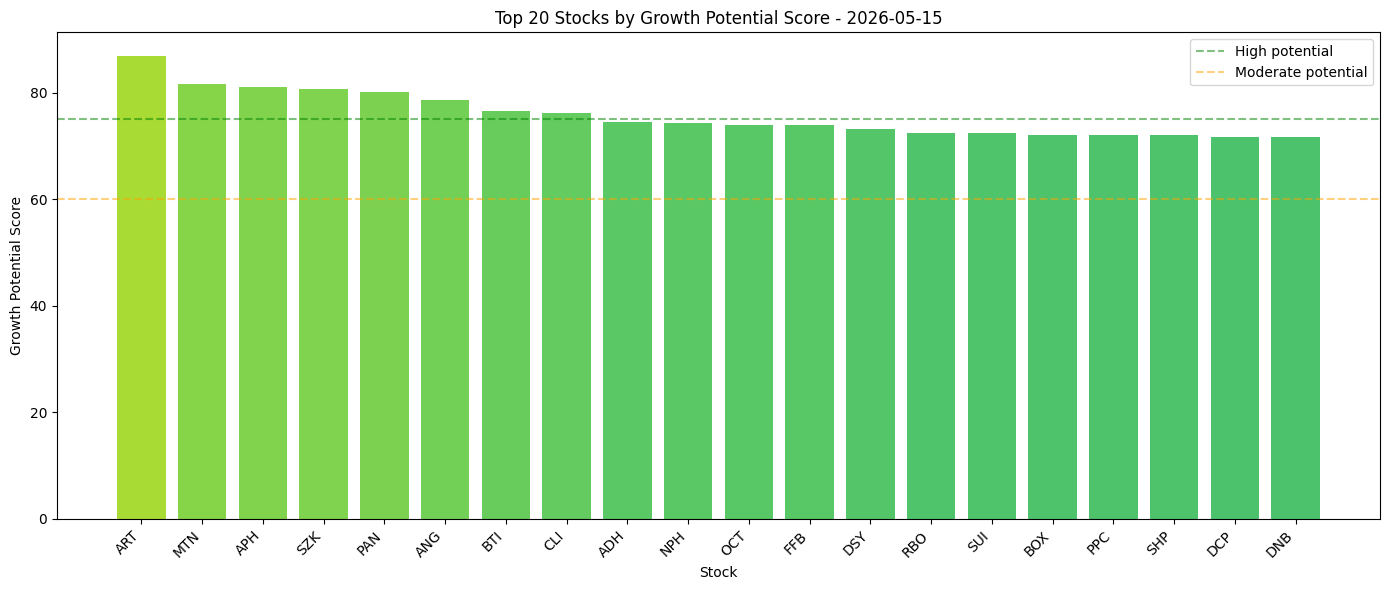

In [17]:
# Top 20 stocks bar chart
import matplotlib.pyplot as plt

# Get aggressive ranking
aggressive = rankings['aggressive_growth']
top_20 = aggressive.head(20)

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.viridis(top_20['growth_potential_score_aggressive'] / 100)
bars = ax.bar(top_20['symbol'], top_20['growth_potential_score_aggressive'], color=colors)

ax.set_title(f'Top 20 Stocks by Growth Potential Score - {SNAPSHOT_DATE}')
ax.set_xlabel('Stock')
ax.set_ylabel('Growth Potential Score')
ax.axhline(y=75, color='green', linestyle='--', alpha=0.5, label='High potential')
ax.axhline(y=60, color='orange', linestyle='--', alpha=0.5, label='Moderate potential')
plt.xticks(rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Score components breakdown for top 10
aggressive = rankings['aggressive_growth']
top_10 = aggressive.head(10).copy()

fig, ax = plt.subplots(figsize=(12, 6))

# Get score components
score_cols = ['momentum_score', 'fundamental_growth_score', 'quality_score']
available_scores = [c for c in score_cols if c in top_10.columns]

x = np.arange(len(top_10))
width = 0.25

for i, col in enumerate(available_scores):
    offset = (i - len(available_scores)/2 + 0.5) * width
    ax.bar(x + offset, top_10[col], width, label=col.replace('_score', '').replace('_', ' ').title())

ax.set_xlabel('Stock')
ax.set_ylabel('Score (0-100)')
ax.set_title(f'Score Component Breakdown - Top 10 Stocks')
ax.set_xticks(x)
ax.set_xticklabels(top_10['symbol'], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()


# ## 7. Look Up Specific Stock


## 7. Look Up Specific Stock

In [ ]:
# Look up a specific stock
TICKER = "SBK"  # Change this

snapshot = rankings['snapshot']
aggressive = rankings['aggressive_growth']
guardrails = rankings['growth_with_guardrails']

stock = snapshot[snapshot['symbol'] == TICKER]

if len(stock) > 0:
    stock_data = stock.iloc[0]
    print(f"STOCK DETAILS: {TICKER}")
    print("="*50)
    print(f"Sector:        {stock_data.get('sector', 'N/A')}")
    print(f"Price:         {stock_data.get('price', 'N/A')}")
    print(f"Coverage:      {stock_data.get('coverage_score', 0)*100:.0f}%")
    print()
    print("Performance:")
    print(f"  1 Month:     {stock_data.get('perf_1m', 'N/A'):.1f}%" if pd.notna(stock_data.get('perf_1m')) else "  1 Month:     N/A")
    print(f"  3 Month:     {stock_data.get('perf_3m', 'N/A'):.1f}%" if pd.notna(stock_data.get('perf_3m')) else "  3 Month:     N/A")
    print(f"  6 Month:     {stock_data.get('perf_6m', 'N/A'):.1f}%" if pd.notna(stock_data.get('perf_6m')) else "  6 Month:     N/A")
    print(f"  1 Year:      {stock_data.get('perf_1y', 'N/A'):.1f}%" if pd.notna(stock_data.get('perf_1y')) else "  1 Year:      N/A")
    print()

    # Check ranking
    agg_rank = aggressive[aggressive['symbol'] == TICKER]
    guard_rank = guardrails[guardrails['symbol'] == TICKER]

    if len(agg_rank) > 0:
        print(f"Aggressive Rank:  #{int(agg_rank.iloc[0]['rank'])} (Score: {agg_rank.iloc[0]['growth_potential_score_aggressive']:.1f})")
    else:
        print("Aggressive Rank:  Did not pass gates")

    if len(guard_rank) > 0:
        print(f"Guardrails Rank:  #{int(guard_rank.iloc[0]['rank'])} (Score: {guard_rank.iloc[0]['growth_potential_score_guardrails']:.1f})")
    else:
        print("Guardrails Rank:  Did not pass gates")
else:
    print(f"Stock {TICKER} not found in snapshot")


# ## 8. Growth Quality Heatmap
#
# Multi-dimensional growth analysis: which stocks have BROAD-BASED growth?


In [18]:
# Growth Quality Heatmap
snapshot = rankings['snapshot']
growth_cols = ['eps_growth_ttm', 'revenue_growth_ttm', 'ebitda_growth_ttm',
               'fcf_growth_ttm', 'net_income_growth_ttm', 'gross_profit_growth_ttm']
available_growth = [c for c in growth_cols if c in snapshot.columns]

if len(available_growth) >= 3:
    growth_df = snapshot[['symbol', 'sector'] + available_growth].copy()
    growth_df['growth_signals'] = (growth_df[available_growth] > 10).sum(axis=1)
    growth_df = growth_df.sort_values('growth_signals', ascending=False).head(20)

    if len(growth_df) > 0:
        import matplotlib.colors as mcolors

        fig, ax = plt.subplots(figsize=(14, 8))
        labels = {
            'eps_growth_ttm': 'EPS', 'revenue_growth_ttm': 'Revenue',
            'ebitda_growth_ttm': 'EBITDA', 'fcf_growth_ttm': 'FCF',
            'net_income_growth_ttm': 'Net Income', 'gross_profit_growth_ttm': 'Gross Profit'
        }
        matrix = growth_df[available_growth].values
        matrix_clipped = np.clip(matrix, -50, 100)
        cmap = plt.cm.RdYlGn
        norm = mcolors.TwoSlopeNorm(vmin=-50, vcenter=0, vmax=100)

        im = ax.imshow(matrix_clipped, cmap=cmap, norm=norm, aspect='auto')
        ax.set_xticks(range(len(available_growth)))
        ax.set_xticklabels([labels.get(c, c) for c in available_growth], rotation=45, ha='right')
        ax.set_yticks(range(len(growth_df)))
        ax.set_yticklabels([f"{row['symbol']} ({int(row['growth_signals'])})" for _, row in growth_df.iterrows()])
        ax.set_title(f'Growth Quality Heatmap (Top 20) - {SNAPSHOT_DATE}')

        for i in range(len(growth_df)):
            for j in range(len(available_growth)):
                val = matrix[i, j]
                if not np.isnan(val):
                    color = 'white' if abs(val) > 40 else 'black'
                    ax.text(j, i, f"{val:.0f}%", ha='center', va='center', fontsize=7, color=color)
                else:
                    ax.text(j, i, '---', ha='center', va='center', fontsize=7, color='gray')

        plt.colorbar(im, ax=ax, label='Growth %', shrink=0.8)
        plt.tight_layout()
        plt.show()
else:
    print('Not enough growth columns available for heatmap')


# ## 9. Technical Regime Summary
#
# Market-wide overview: how many stocks are oversold/overbought across indicators?


Not enough growth columns available for heatmap


## 8. Export Results

In [ ]:
# Technical regime
snapshot = rankings['snapshot']

tech_indicators = {
    'rsi_14': ('RSI 14', 30, 70),
    'stochastic_k_1d': ('Stoch %K', 20, 80),
    'cci_20_1d': ('CCI 20', -100, 100),
}
available_tech = {k: v for k, v in tech_indicators.items() if k in snapshot.columns}

if available_tech:
    fig, axes = plt.subplots(1, len(available_tech), figsize=(5 * len(available_tech), 4))
    if len(available_tech) == 1:
        axes = [axes]

    for ax, (col, (name, os_thresh, ob_thresh)) in zip(axes, available_tech.items()):
        data = snapshot[col].dropna()
        n_os = (data <= os_thresh).sum()
        n_ob = (data >= ob_thresh).sum()
        n_neutral = len(data) - n_os - n_ob

        bars = ax.bar(['Oversold', 'Neutral', 'Overbought'], [n_os, n_neutral, n_ob],
                      color=['#22c55e', '#94a3b8', '#ef4444'])
        ax.set_title(f'{name} (OS<={os_thresh}, OB>={ob_thresh})')
        ax.set_ylabel('# Stocks')
        for bar, val in zip(bars, [n_os, n_neutral, n_ob]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    str(val), ha='center', fontsize=10, fontweight='bold')

    plt.suptitle(f'Market Technical Regime - {SNAPSHOT_DATE}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    header = f"{'Indicator':15} | {'Oversold':>10} | {'Neutral':>10} | {'Overbought':>10}"
    print(f"\n{header}")
    print(f"{'-'*55}")
    for col, (name, os_thresh, ob_thresh) in available_tech.items():
        data = snapshot[col].dropna()
        n_os = (data <= os_thresh).sum()
        n_ob = (data >= ob_thresh).sum()
        n_neutral = len(data) - n_os - n_ob
        print(f"{name:15} | {n_os:10} | {n_neutral:10} | {n_ob:10}")
else:
    print('No technical indicator columns available')


# ## 10. Balance Sheet Strength Ranking


## 🔄 Refresh News for Current Ticker

Re-fetch the latest news for the **TICKER** variable defined in the deep-dive cell above.  
Bypasses the local cache so you always get fresh articles.

In [ ]:
# Balance sheet fortress score
bs_cols = ['cash_to_debt_ratio', 'current_ratio', 'debt_to_assets_annual']
available_bs = [c for c in bs_cols if c in snapshot.columns]

if len(available_bs) >= 2:
    bs_df = snapshot[['symbol', 'sector'] + available_bs].dropna(subset=available_bs, how='all').copy()
    if 'cash_to_debt_ratio' in bs_df.columns:
        bs_df['cd_score'] = bs_df['cash_to_debt_ratio'].clip(0, 5) / 5
    else:
        bs_df['cd_score'] = 0.5
    if 'current_ratio' in bs_df.columns:
        bs_df['cr_score'] = bs_df['current_ratio'].clip(0, 4) / 4
    else:
        bs_df['cr_score'] = 0.5
    if 'debt_to_assets_annual' in bs_df.columns:
        bs_df['da_score'] = 1 - bs_df['debt_to_assets_annual'].clip(0, 1)
    else:
        bs_df['da_score'] = 0.5

    bs_df['fortress_score'] = (bs_df['cd_score'] + bs_df['cr_score'] + bs_df['da_score']) / 3 * 100
    bs_df = bs_df.sort_values('fortress_score', ascending=False)

    print(f"\n{'='*70}")
    print('BALANCE SHEET STRENGTH - Top 15 Financial Fortresses')
    print(f"{'='*70}")
    header = f"{'Symbol':12} | {'Cash/Debt':>10} | {'Current':>8} | {'D/A %':>8} | {'Score':>6}"
    print(header)
    print(f"{'-'*60}")
    for _, row in bs_df.head(15).iterrows():
        cd_val = row.get('cash_to_debt_ratio', np.nan)
        cd = f"{cd_val:.2f}" if not pd.isna(cd_val) else '  N/A'
        cr_val = row.get('current_ratio', np.nan)
        cr = f"{cr_val:.2f}" if not pd.isna(cr_val) else '  N/A'
        da_val = row.get('debt_to_assets_annual', np.nan)
        da = f"{da_val*100:.0f}%" if not pd.isna(da_val) else ' N/A'
        print(f"{row['symbol']:12} | {cd:>10} | {cr:>8} | {da:>8} | {row['fortress_score']:5.0f}")
else:
    print('Not enough balance sheet columns for fortress ranking')




# ## 11. Export Results


In [ ]:
# Export top picks to CSV
output_dir = project_dir / 'outputs'
output_dir.mkdir(exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Get rankings
aggressive = rankings['aggressive_growth']
guardrails = rankings['growth_with_guardrails']

# Top 20 aggressive
agg_path = output_dir / f"jse_aggressive_top20_{SNAPSHOT_DATE}_{timestamp}.csv"
aggressive.head(20).to_csv(agg_path, index=False)
print(f"Saved: {agg_path}")

# Top 20 guardrails
guard_path = output_dir / f"jse_guardrails_top20_{SNAPSHOT_DATE}_{timestamp}.csv"
guardrails.head(20).to_csv(guard_path, index=False)
print(f"Saved: {guard_path}")
